# 12 - Temporal Pattern Analysis

This notebook investigates how dissolved oxygen and water temperature vary according to time of day and environmental conditions.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "aquasensor_final.csv",
    low_memory=False
)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

df["hour"] = df["timestamp"].dt.hour

df.head()

,timestamp,sensor_id,sensor_name,temperature,dissolved_oxygen_mgl,dissolved_oxygen_pct,air_temperature_c,sunshine_wm2,cloud_cover_pct,hour,...,do_mgl_next_60min,do_pct_next_60min,do_mgl_next_75min,do_pct_next_75min,do_mgl_next_90min,do_pct_next_90min,do_mgl_next_105min,do_pct_next_105min,do_mgl_next_120min,do_pct_next_120min
0,2025-06-01 00:04:48,941115,Derwent 13-50,13.0,9.7,91.2,11.3,0.0,17.0,0,...,9.7,90.5,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9
1,2025-06-01 00:16:44,941115,Derwent 13-50,12.9,9.7,91.1,11.3,0.0,17.0,0,...,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8
2,2025-06-01 00:28:41,941115,Derwent 13-50,12.9,9.7,90.9,11.3,0.0,17.0,0,...,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7
3,2025-06-01 00:40:37,941115,Derwent 13-50,12.8,9.7,90.7,11.3,0.0,17.0,0,...,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6
4,2025-06-01 00:52:33,941115,Derwent 13-50,12.8,9.7,90.5,11.3,0.0,17.0,0,...,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6,9.6,89.5


In [2]:
hourly = (
    df.groupby("hour")
    .agg(
        mean_do=("dissolved_oxygen_mgl", "mean"),
        mean_temperature=("temperature", "mean")
    )
    .reset_index()
)

hourly

,hour,mean_do,mean_temperature
0,0,11.237737,9.467061
1,1,11.232073,9.410378
2,2,11.235017,9.369538
3,3,11.252667,9.300788
4,4,11.266313,9.245179
5,5,11.283130,9.192389
6,6,11.307937,9.143179
7,7,11.380615,9.136508
8,8,11.540359,9.096259
9,9,11.701583,9.221890


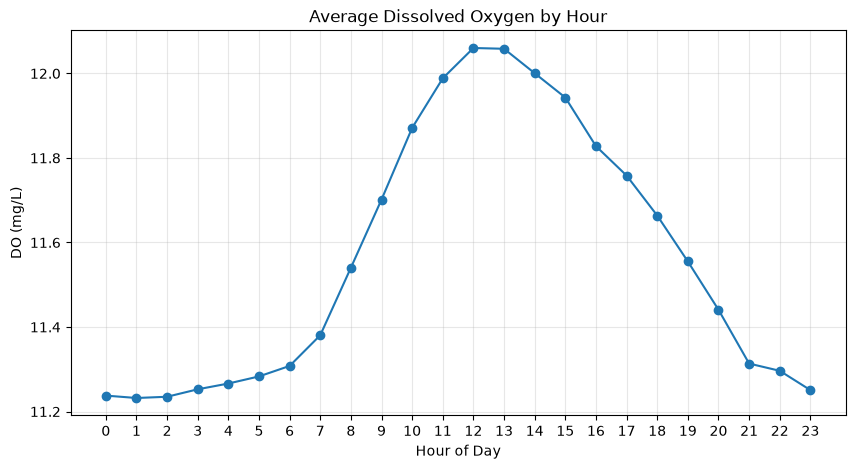

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly["hour"],
    hourly["mean_do"],
    marker="o",
    label="Mean DO"
)

plt.title("Average Dissolved Oxygen by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("DO (mg/L)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

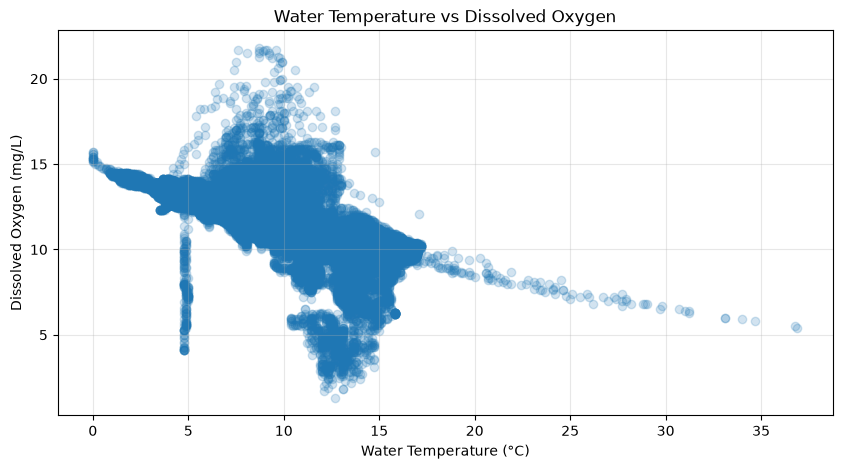

In [4]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["temperature"],
    df["dissolved_oxygen_mgl"],
    alpha=0.2
)

plt.title("Water Temperature vs Dissolved Oxygen")
plt.xlabel("Water Temperature (°C)")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.grid(alpha=0.3)
plt.show()

## Interpretation

Temporal analysis provides additional evidence for the relationship between environmental conditions and dissolved oxygen. In particular, examining temperature alongside DO supports interpretation of the inverse temperature–oxygen relationship discussed in the literature.